## Minimal Preprocessing

In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('../data/raw/aps_failure_training_set.csv', na_values='na', skiprows=20)
test_df = pd.read_csv('../data/raw/aps_failure_test_set.csv', na_values='na', skiprows=20)

train_df['class'] = train_df['class'].map({'neg': 0, 'pos': 1})
test_df['class'] = test_df['class'].map({'neg': 0, 'pos': 1})

X_train = train_df.drop(columns=['class'])
y_train = train_df['class']

X_test = test_df.drop(columns=['class'])
y_test = test_df['class']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive class ratio in train: {y_train.mean()}")

X_train shape: (60000, 170)
X_test shape: (16000, 170)
Positive class ratio in train: 0.016666666666666666


## LightGBM + Custom Cost Optimization

In [4]:
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=ratio, 
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

y_proba = lgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"Raw ROC-AUC: {auc}")

[LightGBM] [Info] Number of positive: 1000, number of negative: 59000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39118
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 170
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Start training from score -4.077537
Raw ROC-AUC: 0.9959307946666667


In [5]:
cost_fp = 10
cost_fn = 500

best_cost = float('inf')
best_threshold = 0.0

thresholds = np.linspace(0.001, 0.999, 1000)
costs = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(cost)
    
    if cost < best_cost:
        best_cost = cost
        best_threshold = t
        best_fp = fp
        best_fn = fn

print(f"Optimal Threshold: {best_threshold}")
print(f"False Positives (Cost $10): {best_fp}")
print(f"False Negatives (Cost $500): {best_fn}")
print(f"Total Minimal Cost: ${best_cost}")

Optimal Threshold: 0.001
False Positives (Cost $10): 563
False Negatives (Cost $500): 6
Total Minimal Cost: $8630


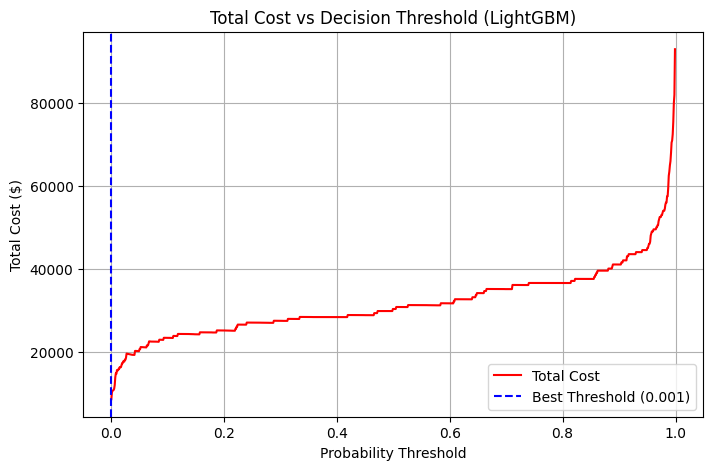

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, label='Total Cost', color='red')
plt.axvline(best_threshold, linestyle='--', color='blue', label=f'Best Threshold ({best_threshold:.3f})')
plt.title('Total Cost vs Decision Threshold (LightGBM)')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.grid(True)
plt.show()